In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.patches as mpatches
import cmocean

from scipy.stats import genextreme as gev

# -----------------------
# Paths
# -----------------------
path_event = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/event_at_tdailymax_merged_1940_2024.nc"
path_txx   = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Config (same as your plot)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# Paris box
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# Other box (example you had)
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

# -----------------------
# 1) Load datasets
# -----------------------
event_max = xr.open_dataset(path_event)["event_max"].sortby("lon")
ds_txx    = xr.open_dataset(path_txx).sortby("lon")

# -----------------------
# 2) Apply same lat band
# -----------------------
event_band = sel_lat_band(event_max, lat_min, lat_max)
ds_band    = sel_lat_band(ds_txx,   lat_min, lat_max)

# Identify the time-like dimension used for fitting (event series)
# (Most likely "year"; fallback to "time" if needed)
time_dim = "year" if "year" in event_band.dims else "time"

# -----------------------
# 3) Land mask (same approach)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(event_band["lon"], event_band["lat"]) == 0)

event_land = event_band.where(land_mask)
# We'll also mask the target field later so plots match
# (masking does not affect the fit if done before fitting; here it does)
# If you'd rather fit over ocean too, move the .where(land_mask) later.

# -----------------------
# 5) Fit GEV parameters to event_max per grid cell
# -----------------------
# Dask chunking (optional but usually helpful on HPC)
event_land = event_land.chunk({time_dim: -1, "lat": 40, "lon": 80})

def gev_fit_1d(x, min_n=30):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < min_n:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)
    try:
        c, loc, scale = gev.fit(x)  # MLE
        if (not np.isfinite(scale)) or (scale <= 0):
            return np.array([np.nan, np.nan, np.nan], dtype=np.float64)
        return np.array([c, loc, scale], dtype=np.float64)
    except Exception:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

params = xr.apply_ufunc(
    gev_fit_1d,
    event_land,
    input_core_dims=[[time_dim]],
    output_core_dims=[["param"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float64],
    output_sizes={"param": 3},
).assign_coords(param=["c", "loc", "scale"])

c = params.sel(param="c")
loc = params.sel(param="loc")
scale = params.sel(param="scale")

# -----------------------
# 6) Save GEV parameters into a file
# -----------------------
# c, loc, scale come from params.sel(param="...")

c2     = c.reset_coords(drop=True)
loc2   = loc.reset_coords(drop=True)
scale2 = scale.reset_coords(drop=True)

ds_params = xr.Dataset(
    {
        "gev_shape_c": c2,
        "gev_loc": loc2,
        "gev_scale": scale2,
    }
)

outpath = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/gev_params_eventmax_1940_2024.nc"
ds_params.to_netcdf(outpath)

print("Saved GEV parameters to:", outpath)

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.patches as mpatches
import cmocean

from scipy.stats import genextreme as gev

# -----------------------
# Paths
# -----------------------
path_event = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/event_at_tdailymax_merged_1940_2024.nc"
path_txx   = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Config (same as your plot)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# Paris box
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# Other box (example you had)
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

# -----------------------
# 1) Load datasets
# -----------------------
event_max = xr.open_dataset(path_event)["event_max"].sortby("lon")
ds_txx    = xr.open_dataset(path_txx).sortby("lon")

# -----------------------
# 2) Apply same lat band
# -----------------------
event_band = sel_lat_band(event_max, lat_min, lat_max)
ds_band    = sel_lat_band(ds_txx,   lat_min, lat_max)

# Identify the time-like dimension used for fitting (event series)
time_dim = "year" if "year" in event_band.dims else "time"

# -----------------------
# 3) Land mask (same approach)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(event_band["lon"], event_band["lat"]) == 0)

event_land = event_band.where(land_mask)

# -----------------------
# 5) Fit GEV parameters to event_max per grid cell
#    BUT: exclude the maximum value per grid cell before fitting
# -----------------------
event_land = event_land.chunk({time_dim: -1, "lat": 40, "lon": 80})

def gev_fit_1d_exclude_max(x, min_n=30):
    """
    Fit GEV to 1D array x after removing the single largest finite value.
    Returns [c, loc, scale] or [nan, nan, nan] if insufficient data / failure.
    """
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]

    # need at least min_n AFTER removing the max -> require min_n + 1 before
    if x.size < (min_n + 1):
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

    # remove exactly one occurrence of the maximum
    imax = np.argmax(x)
    x = np.delete(x, imax)

    if x.size < min_n:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

    try:
        c, loc, scale = gev.fit(x)  # MLE
        if (not np.isfinite(scale)) or (scale <= 0):
            return np.array([np.nan, np.nan, np.nan], dtype=np.float64)
        return np.array([c, loc, scale], dtype=np.float64)
    except Exception:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

params = xr.apply_ufunc(
    gev_fit_1d_exclude_max,
    event_land,
    input_core_dims=[[time_dim]],
    output_core_dims=[["param"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float64],
    output_sizes={"param": 3},
).assign_coords(param=["c", "loc", "scale"])

c = params.sel(param="c")
loc = params.sel(param="loc")
scale = params.sel(param="scale")

# -----------------------
# 6) Save GEV parameters into a file
# -----------------------
c2     = c.reset_coords(drop=True)
loc2   = loc.reset_coords(drop=True)
scale2 = scale.reset_coords(drop=True)

ds_params = xr.Dataset(
    {
        "gev_shape_c": c2,
        "gev_loc": loc2,
        "gev_scale": scale2,
    }
)

outpath = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/gev_params_eventmax_1940_2024_exclmax.nc"
ds_params.to_netcdf(outpath)

print("Saved GEV parameters (excluding per-cell max) to:", outpath)

In [ ]:
import xarray as xr
import numpy as np
from scipy.stats import genextreme as gev

# -----------------------
# Load saved GEV parameter file
# -----------------------
ds_params = xr.open_dataset("/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/gev_params_eventmax_1940_2024.nc")

c     = ds_params["gev_shape_c"]
loc   = ds_params["gev_loc"]
scale = ds_params["gev_scale"]


# -----------------------
# 4) Compute target values: t500_premax_3d at hottest TXX (per grid cell)
# -----------------------
txx = ds_band["txx"]  # (year, lat, lon)
i_hot = txx.argmax("year")  # (lat, lon)

t500_hot = ds_band["t500_premax_3d"].isel(year=i_hot)  # (lat, lon)
t500_hot_land = t500_hot.where(land_mask)


# -----------------------
# Return period function
# -----------------------
def return_period(x, c, loc, scale):
    x = np.asarray(x, dtype=np.float64)
    c = np.asarray(c, dtype=np.float64)
    loc = np.asarray(loc, dtype=np.float64)
    scale = np.asarray(scale, dtype=np.float64)

    out = np.full_like(x, np.nan, dtype=np.float64)
    ok = np.isfinite(x) & np.isfinite(c) & np.isfinite(loc) & np.isfinite(scale) & (scale > 0)
    if not np.any(ok):
        return out

    F = np.full_like(x, np.nan, dtype=np.float64)
    F[ok] = gev.cdf(x[ok], c[ok], loc=loc[ok], scale=scale[ok])

    eps = 1e-12
    out[ok] = 1.0 / np.maximum(1.0 - F[ok], eps)
    return out

# -----------------------
# Apply to your t500_hot_land field
# -----------------------
rp_t500_hot = xr.apply_ufunc(
    return_period,
    t500_hot_land, c, loc, scale,
    input_core_dims=[[], [], [], []],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float64],
)

# Cap for plotting
rp_plot = rp_t500_hot.clip(1, 500)


In [ ]:
# -----------------------
# 7) Plot map (your style)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

# --- cap at 200 (plot + colorbar) ---
rp_plot_capped = rp_plot.clip(max=250)

# --- finer level resolution up to 200 ---
# log-spaced gives nice detail at small return periods while still resolving large ones
levels = np.logspace(np.log10(1), np.log10(100), 30)

im = rp_plot.plot(
    ax=ax, transform=data_crs, x="lon", y="lat",
    cmap=cmocean.cm.matter,
    levels=levels,
    add_colorbar=False
)

cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.02, fraction=0.06, aspect=80)

# integer tick marks
tick_locs = np.array([1, 2, 5, 10, 20, 50, 100])
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([str(int(t)) for t in tick_locs])

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles (same as your script)
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("Return period of T500 (at hottest TXX year) under GEV fit to event_max")

fig.subplots_adjust(bottom=0.22)
cbar.set_label("Return period [years] (capped at 200)")

plt.savefig("RP_t500premax3d_at_hottestTXX_under_GEV_eventmax.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import xarray as xr
import numpy as np
import regionmask
from scipy.stats import genextreme as gev

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Config
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

# -----------------------
# 1) Load TXX
# -----------------------
ds_txx = xr.open_dataset(path_txx).sortby("lon")

# pick the TXX variable robustly
if "txx" in ds_txx.data_vars:
    txx = ds_txx["txx"]
elif "TXX" in ds_txx.data_vars:
    txx = ds_txx["TXX"]
else:
    # fallback: first data variable
    txx = ds_txx[list(ds_txx.data_vars)[0]]

# -----------------------
# 2) Apply lat band
# -----------------------
txx_band = sel_lat_band(txx, lat_min, lat_max)

# time-like dimension used for fitting
time_dim = "year" if "year" in txx_band.dims else "time"

# -----------------------
# 3) Land mask (same approach)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(txx_band["lon"], txx_band["lat"]) == 0)

txx_land = txx_band.where(land_mask)

# -----------------------
# 4) Fit GEV parameters to TXX per grid cell
#    BUT: exclude the maximum value per grid cell before fitting
# -----------------------
txx_land = txx_land.chunk({time_dim: -1, "lat": 40, "lon": 80})

def gev_fit_1d_exclude_max(x, min_n=30):
    """
    Fit GEV to 1D array x after removing the single largest finite value.
    Returns [c, loc, scale] or [nan, nan, nan] if insufficient data / failure.
    """
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]

    # need at least min_n AFTER removing the max -> require min_n + 1 before
    if x.size < (min_n + 1):
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

    # remove exactly one occurrence of the maximum
    imax = np.argmax(x)
    x = np.delete(x, imax)

    if x.size < min_n:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

    try:
        c, loc, scale = gev.fit(x)  # MLE
        if (not np.isfinite(scale)) or (scale <= 0):
            return np.array([np.nan, np.nan, np.nan], dtype=np.float64)
        return np.array([c, loc, scale], dtype=np.float64)
    except Exception:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

params = xr.apply_ufunc(
    gev_fit_1d_exclude_max,
    txx_land,
    input_core_dims=[[time_dim]],
    output_core_dims=[["param"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float64],
    output_sizes={"param": 3},
).assign_coords(param=["c", "loc", "scale"])

# split out + clean coords
c     = params.sel(param="c").reset_coords(drop=True)
loc   = params.sel(param="loc").reset_coords(drop=True)
scale = params.sel(param="scale").reset_coords(drop=True)

# -----------------------
# 5) Save GEV parameters
# -----------------------
ds_params = xr.Dataset(
    {
        "gev_shape_c": c,
        "gev_loc": loc,
        "gev_scale": scale,
    }
)

outpath = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_txx_1940_2024_exclmax.nc"
ds_params.to_netcdf(outpath)

print("Saved GEV parameters (excluding per-cell max) to:", outpath)

In [ ]:
import xarray as xr
import numpy as np
import regionmask
from scipy.stats import genextreme as gev

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Config
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

# -----------------------
# 1) Load TXX
# -----------------------
ds_txx = xr.open_dataset(path_txx).sortby("lon")

# pick the TXX variable robustly
if "txx" in ds_txx.data_vars:
    txx = ds_txx["txx"]
elif "TXX" in ds_txx.data_vars:
    txx = ds_txx["TXX"]
else:
    # fallback: first data variable
    txx = ds_txx[list(ds_txx.data_vars)[0]]

# -----------------------
# 2) Apply lat band
# -----------------------
txx_band = sel_lat_band(txx, lat_min, lat_max)

# time-like dimension used for fitting
time_dim = "year" if "year" in txx_band.dims else "time"

# -----------------------
# 3) Land mask (same approach)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(txx_band["lon"], txx_band["lat"]) == 0)

txx_land = txx_band.where(land_mask)

# -----------------------
# 4) Fit GEV parameters to TXX per grid cell
# -----------------------
txx_land = txx_land.chunk({time_dim: -1, "lat": 40, "lon": 80})

def gev_fit_1d(x, min_n=30):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < min_n:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)
    try:
        c, loc, scale = gev.fit(x)  # MLE
        if (not np.isfinite(scale)) or (scale <= 0):
            return np.array([np.nan, np.nan, np.nan], dtype=np.float64)
        return np.array([c, loc, scale], dtype=np.float64)
    except Exception:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64)

params = xr.apply_ufunc(
    gev_fit_1d,
    txx_land,
    input_core_dims=[[time_dim]],
    output_core_dims=[["param"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float64],
    output_sizes={"param": 3},
).assign_coords(param=["c", "loc", "scale"])

# split out + clean coords
c     = params.sel(param="c").reset_coords(drop=True)
loc   = params.sel(param="loc").reset_coords(drop=True)
scale = params.sel(param="scale").reset_coords(drop=True)

# -----------------------
# 5) Save GEV parameters
# -----------------------
ds_params = xr.Dataset(
    {
        "gev_shape_c": c,
        "gev_loc": loc,
        "gev_scale": scale,
    }
)

outpath = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_txx_1940_2024.nc"
ds_params.to_netcdf(outpath)

print("Saved GEV parameters to:", outpath)


In [ ]:
import xarray as xr
import numpy as np
from scipy.stats import genextreme as gev

# -----------------------
# Load saved GEV parameter file (TXX)
# -----------------------
ds_params = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_txx_1940_2024.nc"
)

c     = ds_params["gev_shape_c"]
loc   = ds_params["gev_loc"]
scale = ds_params["gev_scale"]

# -----------------------
# Load TXX data (same preprocessing as before: lat band + land mask)
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
ds_txx = xr.open_dataset(path_txx).sortby("lon")

# pick variable robustly
if "txx" in ds_txx.data_vars:
    txx = ds_txx["txx"]
elif "TXX" in ds_txx.data_vars:
    txx = ds_txx["TXX"]
else:
    txx = ds_txx[list(ds_txx.data_vars)[0]]

# If you already have ds_band + land_mask from earlier, you can skip this whole block
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

txx_band = sel_lat_band(txx, lat_min, lat_max)

import regionmask
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(txx_band["lon"], txx_band["lat"]) == 0)

txx_land = txx_band.where(land_mask)

# -----------------------
# Target values: TXX at "hottest TXX year"
# -----------------------
time_dim = "year" if "year" in txx_land.dims else "time"

# Option A (recommended): hottest year is just the maximum itself
txx_hot_land = txx_land.max(time_dim)  # (lat, lon)

# Option B (equivalent but closer to your original indexing approach)
# i_hot = txx_land.argmax(time_dim)          # (lat, lon)
# txx_hot_land = txx_land.isel({time_dim: i_hot})

# -----------------------
# Return period function
# -----------------------
def return_period(x, c, loc, scale):
    x = np.asarray(x, dtype=np.float64)
    c = np.asarray(c, dtype=np.float64)
    loc = np.asarray(loc, dtype=np.float64)
    scale = np.asarray(scale, dtype=np.float64)

    out = np.full_like(x, np.nan, dtype=np.float64)
    ok = np.isfinite(x) & np.isfinite(c) & np.isfinite(loc) & np.isfinite(scale) & (scale > 0)
    if not np.any(ok):
        return out

    F = np.full_like(x, np.nan, dtype=np.float64)
    F[ok] = gev.cdf(x[ok], c[ok], loc=loc[ok], scale=scale[ok])

    eps = 1e-12
    out[ok] = 1.0 / np.maximum(1.0 - F[ok], eps)
    return out

# -----------------------
# Apply to TXX_hot_land field
# -----------------------
rp_txx_hot = xr.apply_ufunc(
    return_period,
    txx_hot_land, c, loc, scale,
    input_core_dims=[[], [], [], []],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float64],
)

# Cap for plotting (pick your cap)
rp_plot = rp_txx_hot.clip(1, 200)   # or .clip(1, 500) if you prefer


In [ ]:
# -----------------------
# 7) Plot map (your style) — TXX only
# -----------------------
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import cmocean
import numpy as np

proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

# ---- choose cap + apply it consistently ----
cap = 200
rp_plot_capped = rp_plot.clip(1, cap)

# ---- smooth log-spaced levels up to cap ----
levels = np.logspace(np.log10(1), np.log10(cap), 30)

im = rp_plot_capped.plot(
    ax=ax, transform=data_crs, x="lon", y="lat",
    cmap=cmocean.cm.matter,
    levels=levels,
    add_colorbar=False
)

cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.02, fraction=0.06, aspect=80)

# integer-ish tick marks (edit to taste)
tick_locs = np.array([1, 2, 5, 10, 20, 50, 100, 200])
tick_locs = tick_locs[tick_locs <= cap]  # safety if you change cap
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([str(int(t)) for t in tick_locs])
cbar.set_label(f"Return period [years] (capped at {cap})")

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("Return period of TXX (hottest year) under GEV fit to TXX")

fig.subplots_adjust(bottom=0.22)
plt.savefig("RP_TXX_at_hottest_year_under_GEV_TXX.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# -----------------------
# 7) Plot map — distance from hottest TXX to GEV upper bound (TXX params excl max)
# -----------------------
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import cmocean
import regionmask

# Paths
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
path_params = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_txx_1940_2024_exclmax.nc"

# --- load TXX + params ---
ds_txx = xr.open_dataset(path_txx).sortby("lon")
ds_p   = xr.open_dataset(path_params).sortby("lon")

# pick the TXX variable robustly
if "txx" in ds_txx.data_vars:
    txx = ds_txx["txx"]
elif "TXX" in ds_txx.data_vars:
    txx = ds_txx["TXX"]
else:
    txx = ds_txx[list(ds_txx.data_vars)[0]]

# apply same lat band function you already have
txx_band = sel_lat_band(txx, lat_min, lat_max)

# time-like dimension used for max
time_dim = "year" if "year" in txx_band.dims else "time"

# --- land mask (match your earlier approach) ---
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(txx_band["lon"], txx_band["lat"]) == 0)
txx_land = txx_band.where(land_mask)

# hottest recorded TXX per grid cell
txx_hottest = txx_land.max(dim=time_dim, skipna=True)

# --- compute GEV finite upper endpoint (only where c < 0) ---
c     = -ds_p["gev_shape_c"]
loc   = ds_p["gev_loc"]
scale = ds_p["gev_scale"]

# ensure alignment
c, loc, scale, txx_hottest = xr.align(c, loc, scale, txx_hottest, join="inner")

upper_endpoint = xr.where(c < 0, loc - (scale / c), np.nan)

# distance to upper bound: endpoint - hottest
dist_to_upper = upper_endpoint - txx_hottest

# -----------------------
# Plot (same style as your other script)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

# ---- cap at 0 exactly like your first script ----
dist_plot_capped = dist_to_upper.where(dist_to_upper >= 0)

levels = np.linspace(0, 10, 31)

im = dist_plot_capped.plot(
    ax=ax, transform=data_crs, x="lon", y="lat",
    cmap=cmocean.cm.thermal,
    levels=levels,
    add_colorbar=False
)

cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.02, fraction=0.06, aspect=80)
cbar.set_label("GEV upper endpoint − hottest recorded TXX [K] (capped at 0)")

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("Distance of hottest recorded TXX to GEV upper endpoint (GEV fit to TXX, excl per-cell max)")

fig.subplots_adjust(bottom=0.22)
plt.savefig("DIST_hottestTXX_to_GEV_upper_endpoint_eventGEV.png", dpi=300, bbox_inches="tight")
plt.show()

In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import cmocean
import regionmask

# -----------------------
# Config / paths (same as before)
# -----------------------
path_params = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/gev_params_eventmax_1940_2024_exclmax.nc"

# -----------------------
# Paths
# -----------------------
path_txx   = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Config (same as your plot)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# Paris box
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# Other box (example you had)
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

# -----------------------
# 1) Load datasets
# -----------------------
ds_txx    = xr.open_dataset(path_txx).sortby("lon")

# -----------------------
# 2) Apply same lat band
# -----------------------
ds_band    = sel_lat_band(ds_txx,   lat_min, lat_max)

# -----------------------
# 1) Load saved GEV parameter file (event_max fit excl per-cell max)
# -----------------------
ds_params = xr.open_dataset(path_params).sortby("lon")
c     = -ds_params["gev_shape_c"]
loc   = ds_params["gev_loc"]
scale = ds_params["gev_scale"]

# -----------------------
# 2) Build target field: t500_premax_3d at hottest TXX (per grid cell)
#    (same dataset objects as your return-period script)
# -----------------------
# ds_band is already lat-banded in your script; just ensure lon sorted
ds_band = ds_band.sortby("lon")

# robust-ish: pick txx from ds_band
if "txx" in ds_band.data_vars:
    txx = ds_band["txx"]
elif "TXX" in ds_band.data_vars:
    txx = ds_band["TXX"]
else:
    txx = ds_band[list(ds_band.data_vars)[0]]

# identify time dim (your script assumes year)
time_dim = "year" if "year" in txx.dims else "time"

# index of hottest TXX per grid cell
i_hot = txx.argmax(time_dim, skipna=True)  # (lat, lon)

# T500 pre-day max at that timestep per grid cell
t500_hot = ds_band["t500_premax_3d"].isel({time_dim: i_hot})  # (lat, lon)

# -----------------------
# 3) Land mask (same approach as before)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

t500_hot_land = t500_hot.where(land_mask)

# -----------------------
# 4) Compute finite upper endpoint + distance
# -----------------------
# Align grids (safe)
cA, locA, scaleA, t500A = xr.align(c, loc, scale, t500_hot_land, join="inner")

# finite upper endpoint exists only for c < 0
upper_endpoint = xr.where(cA < 0, locA - (scaleA / cA), np.nan)

# distance to upper endpoint
dist_to_upper = upper_endpoint - t500A

# clean up

In [2]:
dist_to_upper = upper_endpoint - t500A
#dist_to_upper = dist_to_upper.where(np.isfinite(dist_to_upper))
#dist_to_upper = dist_to_upper.where(dist_to_upper >= 0)  # optional: drop negative distances

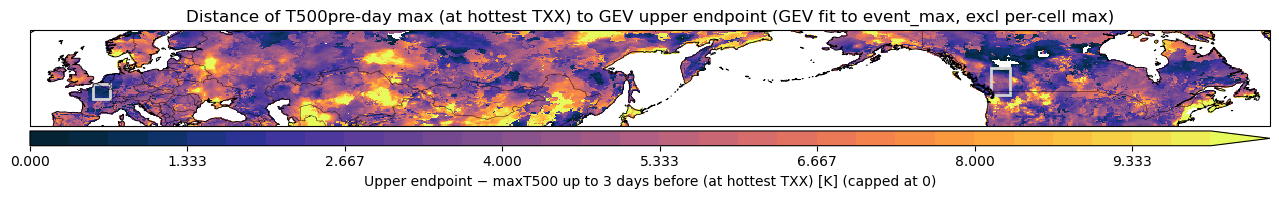

In [3]:
# -----------------------
# 7) Plot map (your style)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

# ---- choose cap (units = same as t500_premax_3d) ----
dist_plot_capped = dist_to_upper.where(dist_to_upper >= 0)

levels = np.linspace(0, 10, 31)

im = dist_plot_capped.plot(
    ax=ax, transform=data_crs, x="lon", y="lat",
    cmap=cmocean.cm.thermal,
    levels=levels,
    add_colorbar=False
)

cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.02, fraction=0.06, aspect=80)
cbar.set_label(f"Upper endpoint − maxT500 up to 3 days before (at hottest TXX) [K] (capped at 0)")

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles (same as your script)
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("Distance of T500pre-day max (at hottest TXX) to GEV upper endpoint (GEV fit to event_max, excl per-cell max)")

fig.subplots_adjust(bottom=0.22)
plt.savefig("DIST_t500premax3d_at_hottestTXX_to_GEV_upper_endpoint_eventGEV.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# -----------------------
# Plot (SWAPPED AXES)
# -----------------------
fig, ax = plt.subplots(figsize=(9, 6))

# observed points
ax.scatter(
    rp_emp,
    txx_sorted,
    s=42, alpha=0.9,
    label="Observed annual TXX"
)

# fitted GEV (using file convention)
ax.plot(
    rp1,
    x1,
    linewidth=2.2,
    label=f"GEV fit using c = shape_file ({shape_file:.3f})"
)

# OPTIONAL: include second curve if you want comparison
# ax.plot(rp2, x2, linestyle="--", linewidth=2.2,
#         label=f"GEV fit using c = -shape_file ({-shape_file:.3f})")

# upper bounds → now HORIZONTAL lines (because TXX is on y-axis)
if np.isfinite(upper1):
    ax.axhline(
        upper1,
        linestyle=":",
        linewidth=1.8,
        label=f"Upper bound (c=shape_file): {upper1:.2f}"
    )

if np.isfinite(upper2):
    ax.axhline(
        upper2,
        linestyle=":",
        linewidth=1.8,
        label=f"Upper bound (c=-shape_file): {upper2:.2f}"
    )

# scales + labels
ax.set_xscale("log")
ax.set_xlabel("Return period [years]")
ax.set_ylabel("TXX [K]")
ax.set_xlim(0.9,100)
ax.set_title(
    "Lytton, BC: GEV return-period plot\n"
    f"nearest grid cell at lat={lat_sel:.2f}, lon={lon_sel:.2f}"
)

ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("Lytton_return_period_vs_TXX_swapped.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

c_plot = dist_to_upper 

im = c_plot.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="viridis", vmin = -10, vmax = 0,
    add_colorbar=False
)

cbar = fig.colorbar(
    im, ax=ax,
    orientation="horizontal",
    pad=0.02, fraction=0.06, aspect=80
)
cbar.set_label("GEV shape parameter c (only where c < -0.1)")

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

ax.set_title("GEV shape parameter c (masked where c >= -0.1)")

fig.subplots_adjust(bottom=0.22)
plt.savefig("gev_shape_c_below_minus_0p1.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

c_plot = upper_endpoint.where(c < -0.1)

im = c_plot.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="viridis",
    add_colorbar=False
)

cbar = fig.colorbar(
    im, ax=ax,
    orientation="horizontal",
    pad=0.02, fraction=0.06, aspect=80
)
cbar.set_label("GEV shape parameter c (only where c < -0.1)")

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

ax.set_title("GEV shape parameter c (masked where c >= -0.1)")

fig.subplots_adjust(bottom=0.22)
plt.savefig("gev_shape_c_below_minus_0p1.png", dpi=300, bbox_inches="tight")
plt.show()

Max TXx: 314.1802
Upper bound: 326.27412136350745
Excluded max TXx: 314.1802


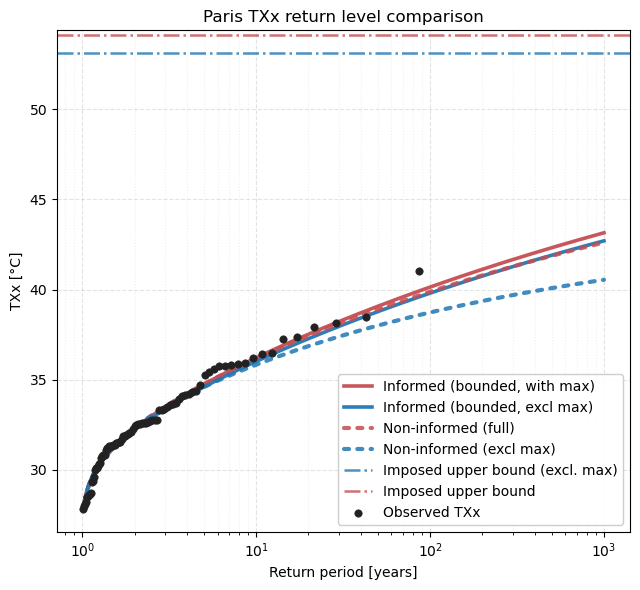

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme
import xarray as xr

ds_fit_boundeds = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_TXX_with_t500hot_upperbound_exclmax_exclmax.nc"
)

ds_fit_boundeds2 = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_TXX_with_t500hot_upperbound.nc"
)

# -----------------------
# Define Paris coordinates
# -----------------------
lat_paris = 48.86
lon_paris = 2.35

# -----------------------
# Extract Paris data
# -----------------------
txx_paris = txx.sel(lat=lat_paris, lon=lon_paris, method="nearest")
fit_paris = ds_fit_boundeds.sel(lat=lat_paris, lon=lon_paris, method="nearest")
fit_paris2 = ds_fit_boundeds2.sel(lat=lat_paris, lon=lon_paris, method="nearest")

# bounded / informed fit (already excl max)
c_b = float(fit_paris["gev_shape_c"])
loc_b = float(fit_paris["gev_loc"])
scale_b = float(fit_paris["gev_scale"])
U = float(fit_paris["upper_bound_used"])

c_b2 = float(fit_paris2["gev_shape_c"])
loc_b2 = float(fit_paris2["gev_loc"])
scale_b2 = float(fit_paris2["gev_scale"])
U2 = float(fit_paris2["upper_bound_used"])

data = txx_paris.values
data = data[np.isfinite(data)]

print("Max TXx:", np.max(data))
print("Upper bound:", U)

# -----------------------
# Non-informed GEV (FULL data)
# -----------------------
c_free_full, loc_free_full, scale_free_full = genextreme.fit(data)

# -----------------------
# Non-informed GEV (EXCLUDING max)
# -----------------------
data_excl = data.copy()
max_val = np.nanmax(data_excl)
data_excl = data_excl[data_excl < max_val]

print("Excluded max TXx:", max_val)

c_free_excl, loc_free_excl, scale_free_excl = genextreme.fit(data_excl)

# -----------------------
# Return level curves
# -----------------------
T = np.logspace(0, 3, 200)
p = 1 - 1 / T

gev_bounded = genextreme(c=c_b, loc=loc_b, scale=scale_b)
gev_bounded2 = genextreme(c=c_b2, loc=loc_b2, scale=scale_b2)
gev_free_full = genextreme(c=c_free_full, loc=loc_free_full, scale=scale_free_full)
gev_free_excl = genextreme(c=c_free_excl, loc=loc_free_excl, scale=scale_free_excl)

x_T_bounded = gev_bounded.ppf(p)
x_T_bounded2 = gev_bounded2.ppf(p)
x_T_free_full = gev_free_full.ppf(p)
x_T_free_excl = gev_free_excl.ppf(p)

# -----------------------
# Empirical return periods
# -----------------------
data_sorted = np.flip(np.sort(data))
n = len(data_sorted)

rank = np.arange(1, n + 1)
T_emp = (n + 1) / rank

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(6.5, 6))

# nicer coherent colors
col_with = "#C44E52"   # keep muted red (nice already)
col_excl = "#1F77B4"   # more saturated blue (classic matplotlib blue)
col_obs  = "#222222"

plt.plot(
    T, x_T_bounded2 - 273.15,
    linewidth=2.6, alpha=0.95, color=col_with,
    label="Informed (bounded, with max)"
)

plt.plot(
    T, x_T_bounded - 273.15,
    linewidth=2.6, alpha=0.95, color=col_excl,
    label="Informed (bounded, excl max)"
)

plt.plot(
    T, x_T_free_full - 273.15,
    linewidth=3.0, alpha=0.85, color=col_with,
    linestyle=(0, (1.2, 2.0)),   # clearer dotted line
    dash_capstyle="round",
    label="Non-informed (full)"
)

plt.plot(
    T, x_T_free_excl - 273.15,
    linewidth=3.0, alpha=0.85, color=col_excl,
    linestyle=(0, (1.2, 2.0)),
    dash_capstyle="round",
    label="Non-informed (excl max)"
)

plt.scatter(
    T_emp, data_sorted - 273.15,
    color=col_obs,
    #edgecolor="white",
    linewidth=0.5,
    s=28,
    zorder=5,
    label="Observed TXx"
)

plt.axhline(
    U - 273.15,
    color=col_excl,
    linewidth=1.8,
    linestyle="-.",
    alpha=0.8,
    label="Imposed upper bound (excl. max)"
)

plt.axhline(
    U2 - 273.15,
    color=col_with,
    linewidth=1.8,
    linestyle="-.",
    alpha=0.8,
    label="Imposed upper bound"
)

plt.xscale("log")
plt.xlabel("Return period [years]")
plt.ylabel("TXx [°C]")

plt.title("Paris TXx return level comparison")

plt.grid(True, which="major", linestyle="--", alpha=0.35)
plt.grid(True, which="minor", linestyle=":", alpha=0.18)

plt.legend(frameon=True, framealpha=0.95)
plt.tight_layout()
plt.show()